In [ ]:
%matplotlib inline
import os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

sys.path.insert(0, os.getcwd())
from model import ModelParams, get_or_run, extract_arrays
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW, LINEWIDTH_IN

apply_style()
NOTEBOOK_DIR = os.path.abspath("")
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, "saved_figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

In [ ]:
# ── Global settings ───────────────────────────────────────────────────
SEEDS   = [0, 1, 2]
NEVENT  = 6
MAX_SEP = 5

# C_min: minimum pairwise correlation a pair must have on Day 2 to be included.
# Most neuron pairs are not meaningfully correlated. Including near-zero pairs
# makes ΔC = (C2-C1)/C2 numerically unstable and floods the distribution with
# noise. C_min culls those pairs, keeping only pairs that are actually correlated
# and therefore informative about representational structure.
# Too low → noise swamps the signal. Too high → too few pairs pass, especially
# for volatility. The paper (Micou & O'Leary) uses C_min = 0.5 for in vivo data.
CMIN = 0.4

_d    = ModelParams()
NSTEP = int(_d.pause + _d.delay * (NEVENT - 1) + _d.Nstim * _d.stim) + 1000

# ── Per-condition parameters (tweak individually) ─────────────────────
# Excitability-driven
E_excit          = 2.0   # excitability block amplitude
E_sigma_excit    = 1.0    # per-neuron random baseline; lower → fewer always-on neurons
E_TD_excit       = 2      # transitions every ~2 days → second peak grows gradually with separation
E_ND_excit       = 3
vol_std_excit    = 0.02  # negligible weight noise
tauw_excit       = 1200.0  # Hebbian time constant (lower → faster/stronger correlations)
taur_excit       = 35.0   # firing-rate time constant

# Volatility-driven
E_vol            = 1.5    # no block excitability
E_sigma_vol      = 1.0    # per-neuron baseline (default)
E_TD_vol         = 3
E_ND_vol         = NEVENT + 1
vol_std_vol      = 0.03   # weight noise amplitude
tauw_vol         = 1200
taur_vol         = 35.0

# Combined
E_comb           = 2.0
E_sigma_comb     = 1.0
E_TD_comb        = 3
E_ND_comb        = 7
vol_std_comb     = 0.03
tauw_comb        = 1200
taur_comb        = 35.0



# E_excit          = 2.0    # excitability block amplitude
# E_sigma_excit    = 1.0    # per-neuron random baseline; lower → fewer always-on neurons
# E_TD_excit       = 3      # transitions every ~2 days → second peak grows gradually with separation
# E_ND_excit       = NEVENT + 1
# vol_std_excit    = 0.03  # negligible weight noise
# tauw_excit       = 1200.0  # Hebbian time constant (lower → faster/stronger correlations)
# taur_excit       = 35.0   # firing-rate time constant

# # Volatility-driven
# E_vol            = 0.0    # no block excitability
# E_sigma_vol      = 1.0    # per-neuron baseline (default)
# E_TD_vol         = NEVENT
# E_ND_vol         = NEVENT + 1
# vol_std_vol      = 0.04   # weight noise amplitude
# tauw_vol         = 600.0
# taur_vol         = 35.0

# # Combined
# E_comb           = 2.0
# E_sigma_comb     = 1.0
# E_TD_comb        = NEVENT
# E_ND_comb        = NEVENT + 1
# vol_std_comb     = 0.04
# tauw_comb        = 600.0
# taur_comb        = 35.0

print(f"NEVENT={NEVENT}  NSTEP={NSTEP}  CMIN={CMIN}")

# ── Assemble conditions ───────────────────────────────────────────────
CONDITIONS = {
    "excit_only": dict(E=E_excit, E_sigma=E_sigma_excit,
                       E_time_divisions=E_TD_excit, E_neuron_divisions=E_ND_excit,
                       vol_std=vol_std_excit, tauw=tauw_excit, taur=taur_excit),
    "vol_only":   dict(E=E_vol,   E_sigma=E_sigma_vol,
                       E_time_divisions=E_TD_vol,   E_neuron_divisions=E_ND_vol,
                       vol_std=vol_std_vol,   tauw=tauw_vol,   taur=taur_vol),
    "combined":   dict(E=E_comb,  E_sigma=E_sigma_comb,
                       E_time_divisions=E_TD_comb,  E_neuron_divisions=E_ND_comb,
                       vol_std=vol_std_comb,  tauw=tauw_comb,  taur=taur_comb),
}
COND_LABELS = {
    "excit_only": "Excitability-driven",
    "vol_only":   "Volatility-driven",
    "combined":   "Combined",
}
COND_COLORS = {
    "excit_only": "#4B89C8",
    "vol_only":   "#E87070",
    "combined":   "#7B5EA7",
}

NEVENT=6  NSTEP=19000  CMIN=0.4


In [19]:
# ── Run simulations ───────────────────────────────────────────────────
results = {}
for cond_name, cond_params in CONDITIONS.items():
    results[cond_name] = []
    for seed in SEEDS:
        p   = ModelParams(Nevent=NEVENT, nstep=NSTEP, seed=seed, **cond_params)
        res = get_or_run(p, f"fig1_3_1_{cond_name}_s{seed}")
        results[cond_name].append(res)
    print(f"Ready: {cond_name}")

Running simulation (seed=0, E=2.0, vol_std=0.02) ...
Running simulation (seed=1, E=2.0, vol_std=0.02) ...
Running simulation (seed=2, E=2.0, vol_std=0.02) ...
Ready: excit_only
Running simulation (seed=0, E=1.5, vol_std=0.03) ...
Running simulation (seed=1, E=1.5, vol_std=0.03) ...
Running simulation (seed=2, E=1.5, vol_std=0.03) ...
Ready: vol_only
Running simulation (seed=0, E=0.5, vol_std=0.01) ...
Running simulation (seed=1, E=0.5, vol_std=0.01) ...
Running simulation (seed=2, E=0.5, vol_std=0.01) ...
Ready: combined


In [20]:
# ── Analysis helpers ──────────────────────────────────────────────────

def compute_delta_c(result, days_apart, cmin):
    """ΔC = (C2 - C1) / C2  for neuron pairs where C2 >= cmin."""
    p   = result["params"]
    r   = extract_arrays(result)["r"]
    dts = result["day_timesteps"]
    tri = np.triu_indices(p.N, k=1)
    all_dc = []
    for start in range(p.Nevent - days_apart):
        r1 = r[:, dts[start]:dts[start + 1]]
        r2 = r[:, dts[start + days_apart]:dts[start + days_apart + 1]]
        C1, C2 = np.corrcoef(r1)[tri], np.corrcoef(r2)[tri]
        mask = C2 >= cmin
        if mask.any():
            all_dc.append((C2[mask] - C1[mask]) / C2[mask])
    return np.concatenate(all_dc) if all_dc else np.array([])


def aggregate_condition(cond_results, cmin, max_sep):
    """Pool ΔC across seeds for each day separation."""
    by_sep = {}
    for sep in range(1, max_sep + 1):
        parts = [compute_delta_c(res, sep, cmin) for res in cond_results]
        valid = [a for a in parts if len(a) > 0]
        by_sep[sep] = np.concatenate(valid) if valid else np.array([])
    return by_sep


def fit_gmm(delta_c):
    """
    Fit a 2-component Gaussian mixture to delta_c.
    Returns (gmm, sorted_idx) where sorted_idx orders components low-mean first,
    or (None, None) if fitting fails or data is insufficient.
    """
    if len(delta_c) < 100:
        return None, None
    X = delta_c.reshape(-1, 1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gmm = GaussianMixture(n_components=2, covariance_type="spherical",
                              random_state=42, n_init=10)
        gmm.fit(X)
    sorted_idx = np.argsort(gmm.means_.flatten())   # [low_idx, high_idx]
    return gmm, sorted_idx


def gmm_curves(gmm, sorted_idx, x):
    """
    Evaluate each Gaussian component and their sum on grid x.
    Returns (total, low_component, high_component).
    """
    means = gmm.means_.flatten()
    stds  = np.sqrt(gmm.covariances_.flatten())  # spherical: shape (n_components,)
    ws    = gmm.weights_
    lo, hi = sorted_idx[0], sorted_idx[1]
    low_c  = ws[lo] * norm.pdf(x, means[lo], stds[lo])
    high_c = ws[hi] * norm.pdf(x, means[hi], stds[hi])
    return low_c + high_c, low_c, high_c


# ── Compute all distributions and fits ───────────────────────────────
print("Computing ΔC distributions and GMM fits...")
dc_data  = {}
gmm_fits = {}
for cond_name, cond_results in results.items():
    dc_data[cond_name]  = aggregate_condition(cond_results, CMIN, MAX_SEP)
    gmm_fits[cond_name] = {}
    for sep in range(1, MAX_SEP + 1):
        dc = dc_data[cond_name][sep]
        gmm_fits[cond_name][sep] = fit_gmm(dc)
    n = sum(len(v) for v in dc_data[cond_name].values())
    print(f"  {cond_name}: {n} total pairs")

Computing ΔC distributions and GMM fits...
  excit_only: 42274 total pairs
  vol_only: 32281 total pairs
  combined: 45290 total pairs


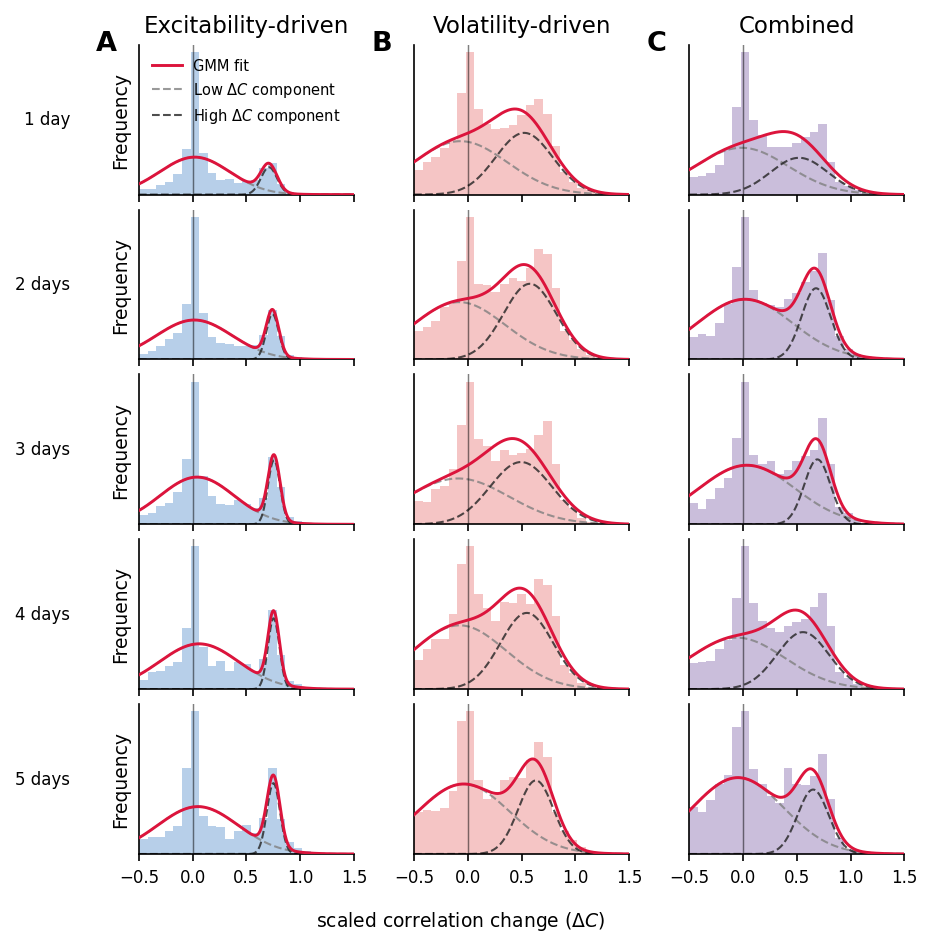

In [7]:
# ── Figure ────────────────────────────────────────────────────────────
apply_style()
plt.rcParams['savefig.bbox'] = None   # exact figsize — no tight expansion beyond LINEWIDTH_IN

from matplotlib.lines import Line2D

COND_KEYS = list(CONDITIONS.keys())
N_CONDS   = len(COND_KEYS)
BINS      = 25
X_GRID    = np.linspace(-0.5, 1.5, 300)

fig = plt.figure(figsize=(LINEWIDTH_IN, 6.5))
gs  = gridspec.GridSpec(
    MAX_SEP, N_CONDS,
    figure=fig,
    left=0.16, right=0.97,
    top=0.93, bottom=0.10,   # extra bottom room for supxlabel
    hspace=0.10, wspace=0.28,
)
ax_hist = {
    sep: [fig.add_subplot(gs[sep - 1, ci]) for ci in range(N_CONDS)]
    for sep in range(1, MAX_SEP + 1)
}

# Column headers and panel labels
for ci, cond_name in enumerate(COND_KEYS):
    ax_hist[1][ci].set_title(COND_LABELS[cond_name],
                              fontsize=FONT["title"] + 1, pad=6)
for ci, label in enumerate("ABC"):
    ax_hist[1][ci].text(-0.20, 1.10, label,
                        transform=ax_hist[1][ci].transAxes,
                        fontsize=FONT["panel_label"], fontweight="bold", va="top")

# Histogram + GMM overlay panels
for sep in range(1, MAX_SEP + 1):
    for ci, cond_name in enumerate(COND_KEYS):
        ax  = ax_hist[sep][ci]
        col = COND_COLORS[cond_name]
        dc  = dc_data[cond_name][sep]

        if len(dc) > 1:
            ax.hist(dc, bins=BINS, density=True,
                    color=col, alpha=0.40, edgecolor="none", range=(-0.5, 1.5))

        gmm, idx = gmm_fits[cond_name][sep]
        if gmm is not None:
            total, low_c, high_c = gmm_curves(gmm, idx, X_GRID)
            ax.plot(X_GRID, total,  color="crimson",  lw=1.4, zorder=3)
            ax.plot(X_GRID, low_c,  color="gray",     lw=1.0, ls="--", alpha=0.8)
            ax.plot(X_GRID, high_c, color="#222222",  lw=1.0, ls="--", alpha=0.8)

        ax.axvline(0, color="black", lw=0.7, alpha=0.5)
        ax.set_xlim(-0.5, 1.5)
        ax.set_yticks([])
        ax.tick_params(labelsize=FONT["tick"])

        if ci == 0:
            label_str = f"{sep} day" if sep == 1 else f"{sep} days"
            ax.text(-0.32, 0.5, label_str, fontsize=FONT["tick"],
                    transform=ax.transAxes, ha="right", va="center")
            ax.set_ylabel("Frequency", fontsize=FONT["axis_label"],
                          rotation=90, labelpad=4)

        if sep < MAX_SEP:
            ax.set_xticklabels([])

# Single shared x-axis label centred below all three columns
fig.supxlabel(r"scaled correlation change ($\Delta C$)",
              fontsize=FONT["axis_label"], y=0.02)

# Legend for GMM curves in top-left panel
legend_elements = [
    Line2D([0], [0], color="crimson", lw=1.4,
           label="GMM fit"),
    Line2D([0], [0], color="gray",    lw=1.0, ls="--", alpha=0.8,
           label="Low $\\Delta C$ component"),
    Line2D([0], [0], color="#222222", lw=1.0, ls="--", alpha=0.8,
           label="High $\\Delta C$ component"),
]
ax_hist[1][0].legend(handles=legend_elements, fontsize=FONT["tick"] - 1,
                     frameon=False, loc="upper right")

plt.show()

In [8]:
# ── Save ──────────────────────────────────────────────────────────────
out_path = os.path.join(FIGURES_DIR, "fig1_3_1_correlation_fingerprint.pdf")
fig.savefig(out_path, dpi=300)   # no bbox_inches="tight" — figure already sized to LINEWIDTH_IN
print(f"Saved -> {out_path}")

Saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig1_3_1_correlation_fingerprint.pdf
